# Машинное обучение, ФКН ВШЭ

# Практическое задание 9. Несбалансированные задачи

## Общая информация
Дата выдачи: 01.03.2026

Мягкий дедлайн: 15.03.2026 23:59 MSK

Жесткий дедлайн: 22.03.2026 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

### В течении всего дз в выодах будет красный цвет тк питон жалуется, что я как бы делю на 0, но это не так и вообще эт ов целом роли не играет. Я думаю что править это бесполезно и долго, пожаулйста, не обращайте внимаени

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [2]:
"""%%bash
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip""";

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

In [10]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [5]:
print(df['Class'].sum()/len(df))

0.001727485630620034


Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [6]:
df['час'] = df['Time']//(60*60)%24
df['день'] = df['Time']//(60*60*24)

Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

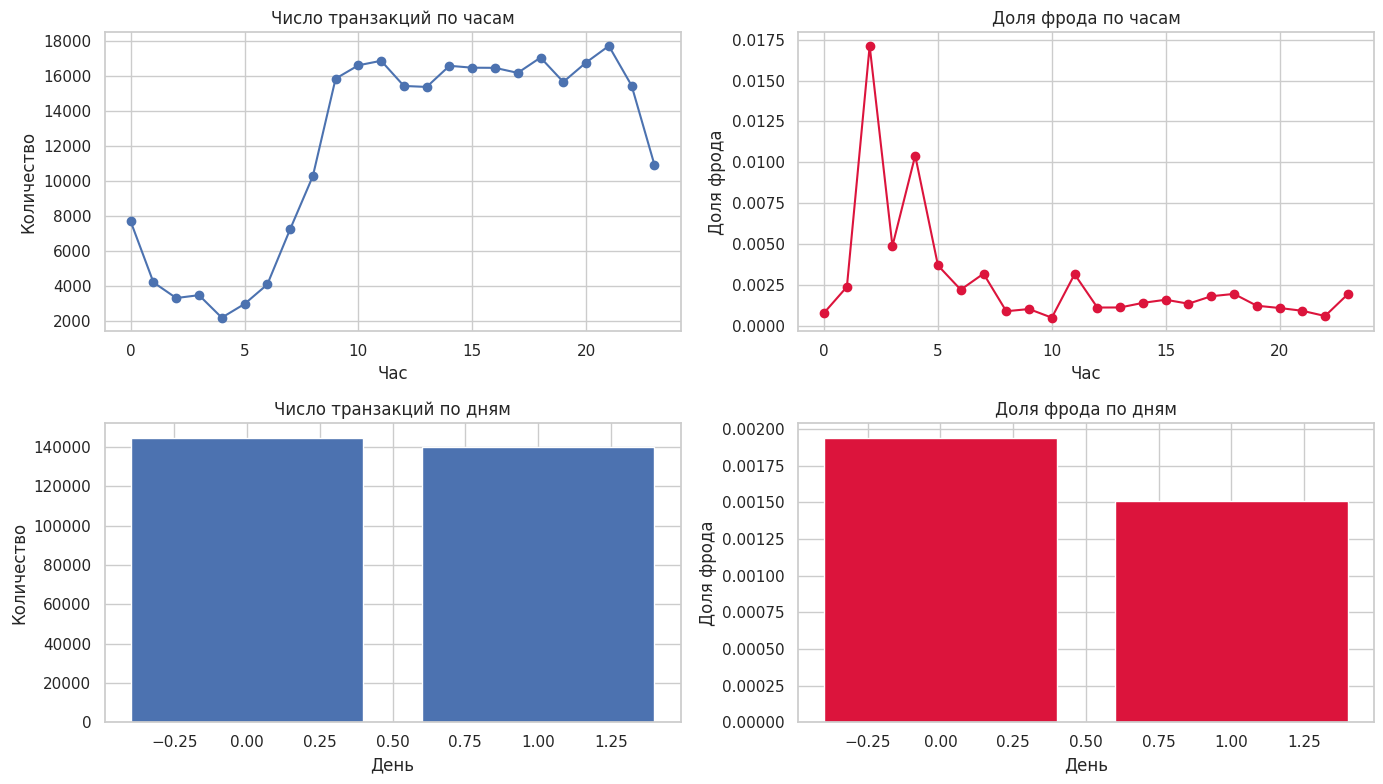

In [7]:
hourly = df.groupby('час').agg(
    total=('Class', 'count'),
    fraud_rate=('Class', 'mean'),
).reset_index()

daily = df.groupby('день').agg(
    total=('Class', 'count'),
    fraud_rate=('Class', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(hourly['час'], hourly['total'], marker='o')
axes[0, 0].set_title('Число транзакций по часам')
axes[0, 0].set_xlabel('Час')
axes[0, 0].set_ylabel('Количество')

axes[0, 1].plot(hourly['час'], hourly['fraud_rate'], marker='o', color='crimson')
axes[0, 1].set_title('Доля фрода по часам')
axes[0, 1].set_xlabel('Час')
axes[0, 1].set_ylabel('Доля фрода')

axes[1, 0].bar(daily['день'], daily['total'])
axes[1, 0].set_title('Число транзакций по дням')
axes[1, 0].set_xlabel('День')
axes[1, 0].set_ylabel('Количество')

axes[1, 1].bar(daily['день'], daily['fraud_rate'], color='crimson')
axes[1, 1].set_title('Доля фрода по дням')
axes[1, 1].set_xlabel('День')
axes[1, 1].set_ylabel('Доля фрода')

plt.tight_layout()
plt.show()

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

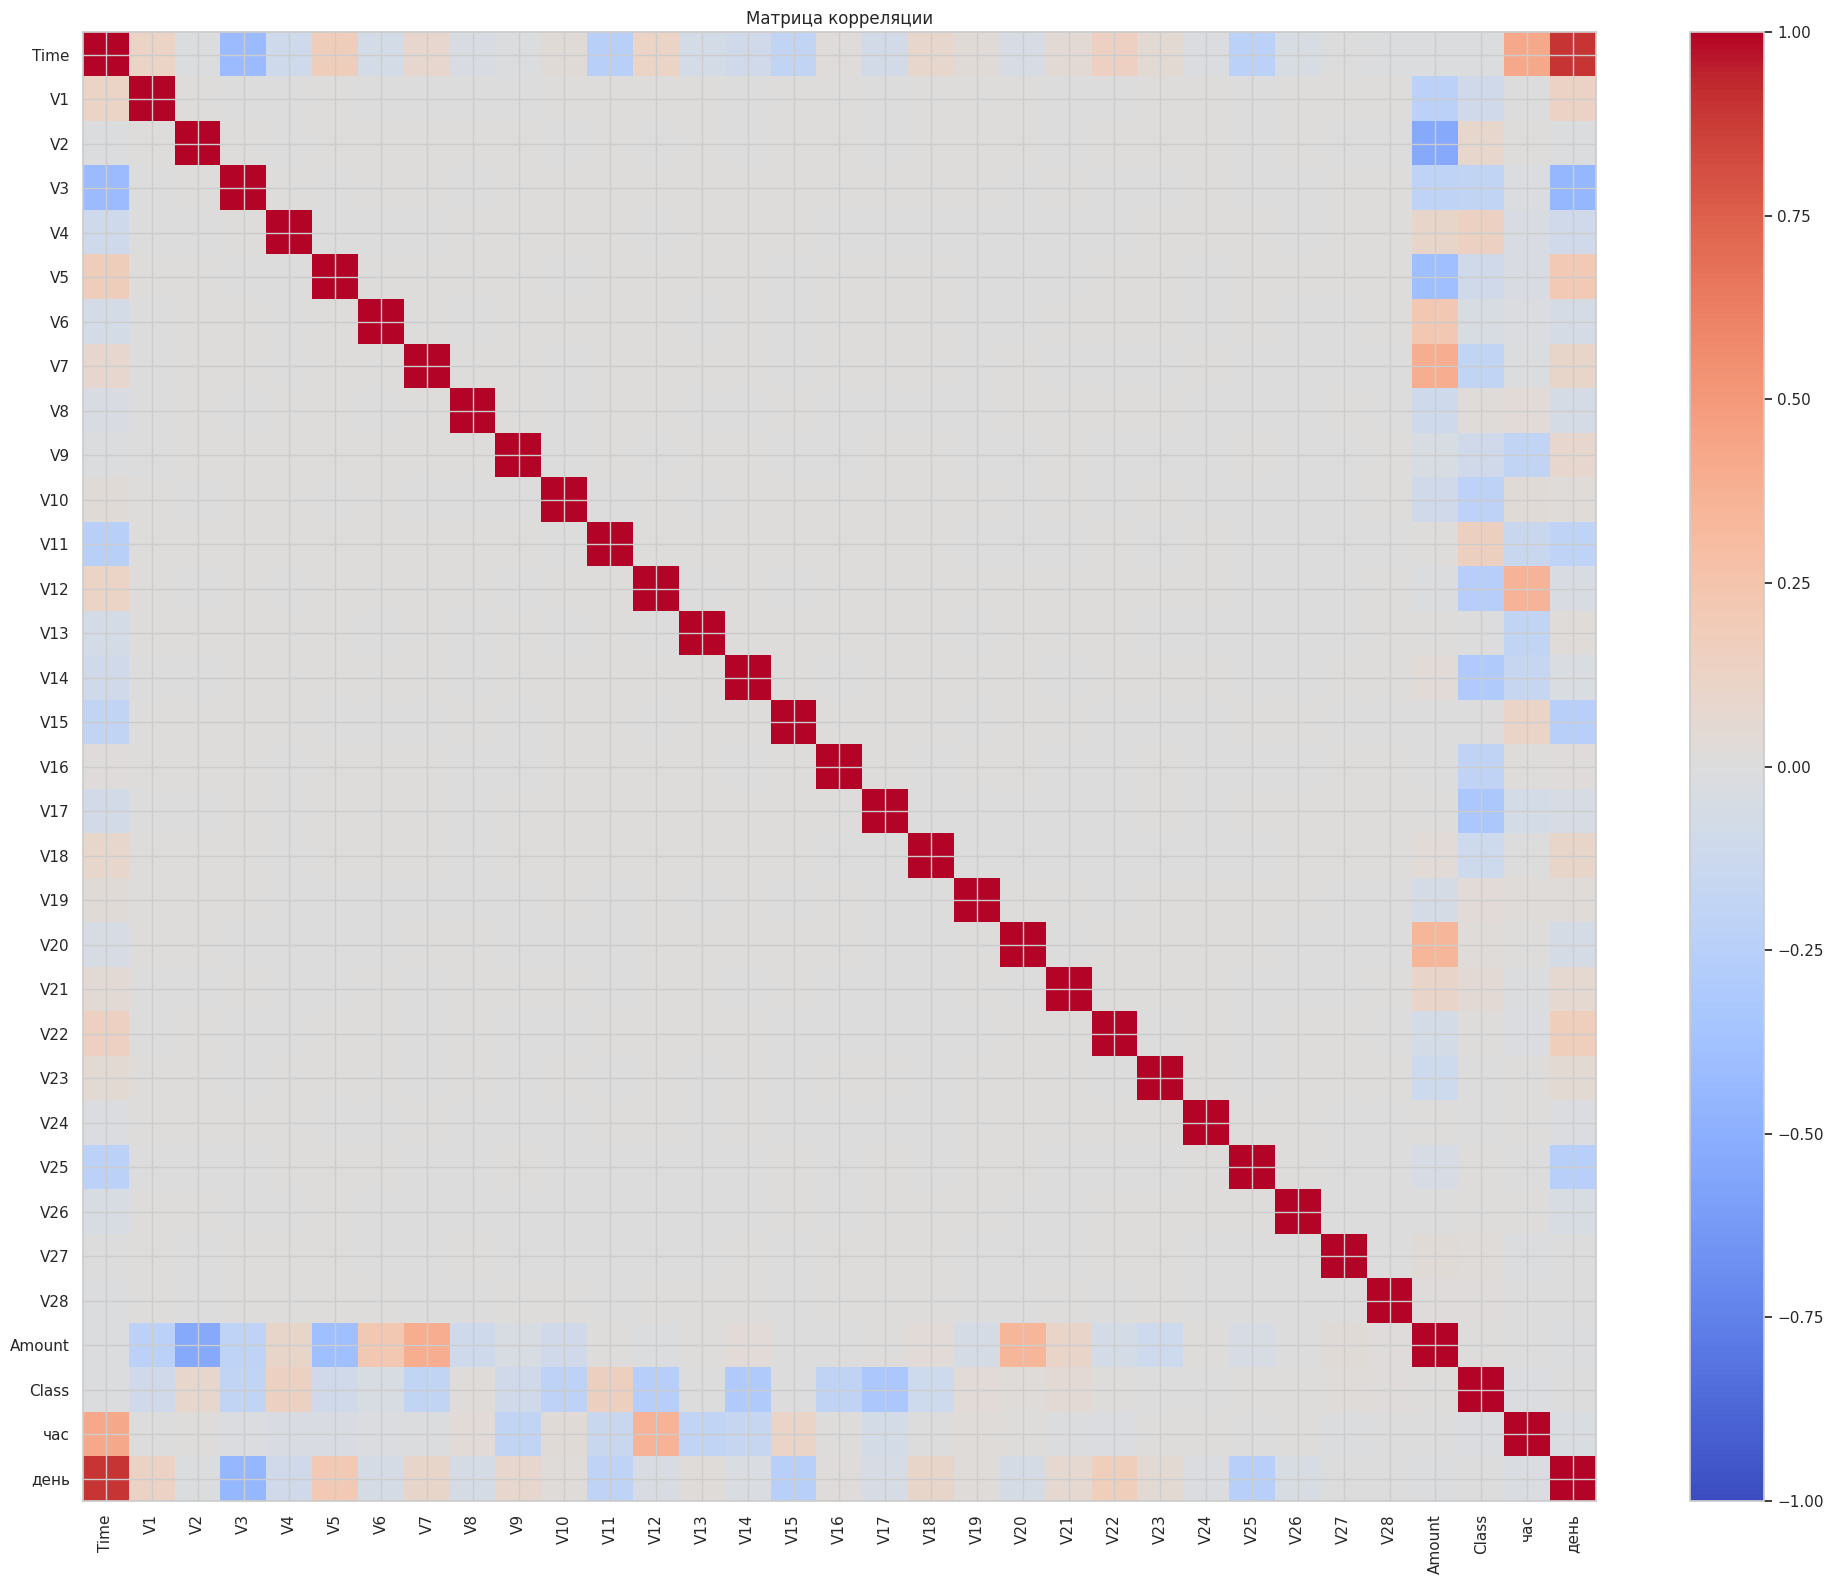

In [8]:
corr = df.corr()
plt.figure(figsize=(20, 16))
plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Матрица корреляции')
plt.tight_layout()
plt.show()

In [11]:
class_corr = df.corr()['Class'].abs().sort_values(ascending=False)
print(class_corr[:10])

Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64


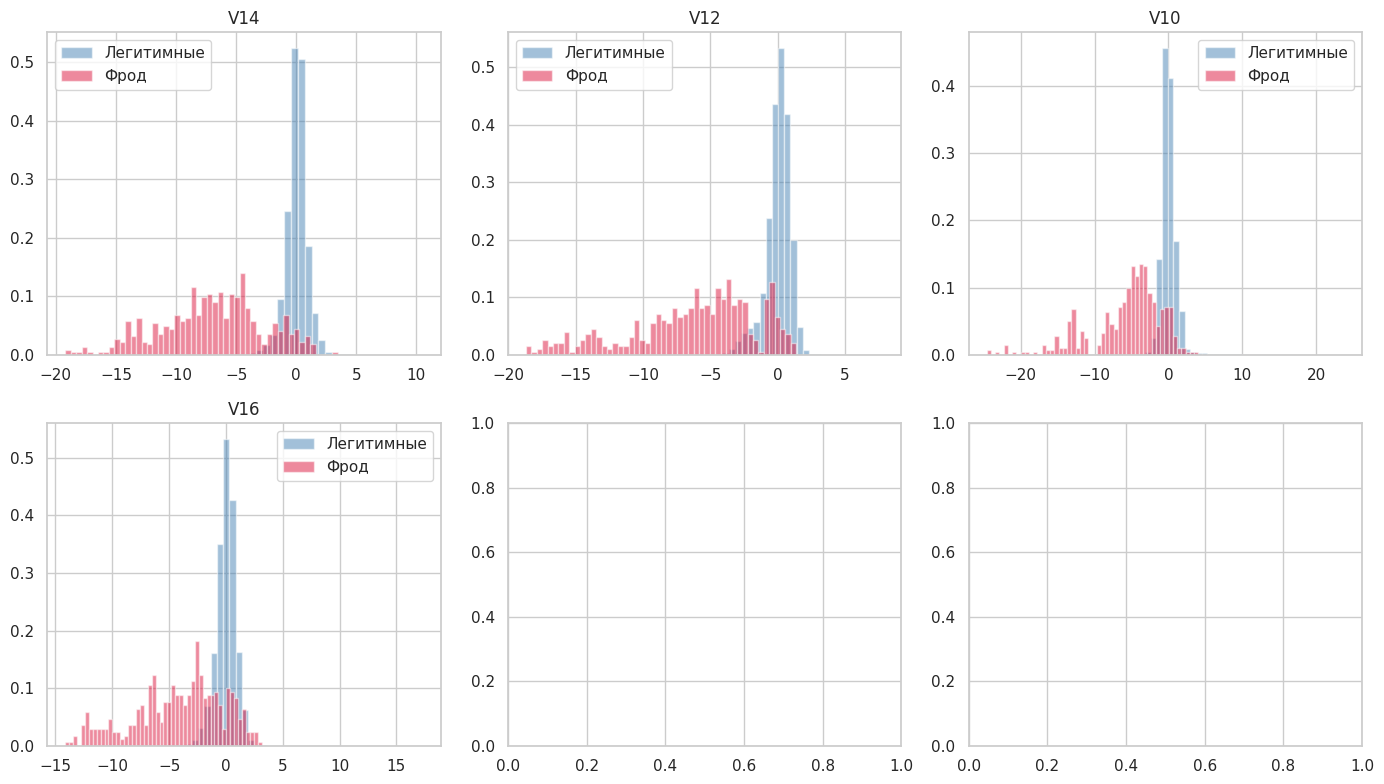

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), class_corr.index[2:6]):
    for label, color in [(0, 'steelblue'), (1, 'crimson')]:
        ax.hist(df[df['Class'] == label][col], bins=50, alpha=0.5,
                density=True, color=color, label=['Легитимные', 'Фрод'][label])
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим. 

In [13]:
n = len(df)
train = df.iloc[:int(n * 0.8)]
valid = df.iloc[int(n * 0.8):int(n * 0.9)]
test  = df.iloc[int(n * 0.9):]

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего "ломаются" на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога. 

In [14]:
naive_acc = (1-df['Class'].mean())
print(naive_acc)

0.9982725143693799


Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [15]:
p_e = ((1 - naive_acc) * 0) + (naive_acc * 1)
kappa = (naive_acc - p_e) / (1 - p_e)
print(kappa)

0.0


Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$ 

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом. 

In [16]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(df['Class'], np.zeros(len(df))).flatten()

mcc = (tp * tn - fp * fn) / ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc

/tmp/ipykernel_55/3347608030.py:5: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5


np.float64(nan)

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`). 

In [17]:
from catboost import CatBoostClassifier

In [18]:
from sklearn.metrics import confusion_matrix, average_precision_score

features = [c for c in df.columns if c != 'Class']
target = 'Class'

X_train, y_train = train[features], train[target]
X_valid, y_valid = valid[features], valid[target]
X_test, y_test  = test[features], test[target]

model = CatBoostClassifier(verbose = 100)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
acc = (y_test == y_pred).mean()
kappa = (acc - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) )) /(1 - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) ))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn)/denom
auc_pr = average_precision_score(y_test, y_proba)

print(f'accuracy: {acc}')
print(f'kappa: {kappa}')
print(f'mcc: {mcc}')
print(f'AUC-PR: {auc_pr}')

Learning rate set to 0.121128
0:	learn: 0.3333486	test: 0.3290991	best: 0.3290991 (0)	total: 116ms	remaining: 1m 55s
100:	learn: 0.0014284	test: 0.0025970	best: 0.0025946 (98)	total: 4.6s	remaining: 40.9s
200:	learn: 0.0010304	test: 0.0026022	best: 0.0025772 (104)	total: 8.73s	remaining: 34.7s
300:	learn: 0.0007179	test: 0.0025795	best: 0.0025534 (257)	total: 12.9s	remaining: 30s
400:	learn: 0.0004773	test: 0.0026434	best: 0.0025534 (257)	total: 17.2s	remaining: 25.7s
500:	learn: 0.0003029	test: 0.0028000	best: 0.0025534 (257)	total: 21.4s	remaining: 21.3s
600:	learn: 0.0002110	test: 0.0030282	best: 0.0025534 (257)	total: 25.6s	remaining: 17s
700:	learn: 0.0001544	test: 0.0031549	best: 0.0025534 (257)	total: 29.8s	remaining: 12.7s
800:	learn: 0.0001151	test: 0.0032829	best: 0.0025534 (257)	total: 33.9s	remaining: 8.43s
900:	learn: 0.0000944	test: 0.0034195	best: 0.0025534 (257)	total: 38.1s	remaining: 4.18s
999:	learn: 0.0000810	test: 0.0035048	best: 0.0025534 (257)	total: 42.2s	remain

Немного переобучилась, но все равно берет лучшие веса для подсчета метрик

Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

In [20]:
print(f'Recall: {tp / (tp + fn)}')

Recall: 0.6363636363636364


**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [28]:
scale = 1/df['Class'].mean() - 1
model = CatBoostClassifier(verbose=100, scale_pos_weight=scale)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
acc = (y_test == y_pred).mean()
kappa = (acc - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) )) /(1 - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) ))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn)/denom
auc_pr = average_precision_score(y_test, y_proba)

print(f'accuracy: {acc}')
print(f'kappa: {kappa}')
print(f'mcc: {mcc}')
print(f'AUC-PR: {auc_pr}')
print(f'Recall: {tp / (tp + fn)}')

Learning rate set to 0.121128
0:	learn: 0.4881190	test: 0.5499280	best: 0.5499280 (0)	total: 53.2ms	remaining: 53.1s
100:	learn: 0.0038010	test: 0.4628678	best: 0.1731085 (14)	total: 4.97s	remaining: 44.2s
200:	learn: 0.0013995	test: 0.5810563	best: 0.1731085 (14)	total: 9.16s	remaining: 36.4s
300:	learn: 0.0012440	test: 0.6045923	best: 0.1731085 (14)	total: 13s	remaining: 30.1s
400:	learn: 0.0012435	test: 0.6045907	best: 0.1731085 (14)	total: 16.7s	remaining: 25s
500:	learn: 0.0012431	test: 0.6046414	best: 0.1731085 (14)	total: 20.5s	remaining: 20.4s
600:	learn: 0.0012426	test: 0.6047384	best: 0.1731085 (14)	total: 24.3s	remaining: 16.2s
700:	learn: 0.0012322	test: 0.6050334	best: 0.1731085 (14)	total: 28s	remaining: 12s
800:	learn: 0.0012320	test: 0.6050393	best: 0.1731085 (14)	total: 31.7s	remaining: 7.86s
900:	learn: 0.0012003	test: 0.6103676	best: 0.1731085 (14)	total: 35.4s	remaining: 3.89s
999:	learn: 0.0012003	test: 0.6103627	best: 0.1731085 (14)	total: 39s	remaining: 0us

best

Хуже baseline. причем намного. скорее всего дело в том что мы взяли вес с потолка, стоит поэкспериментировать

Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части. 

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

Заметим, что во обоих предыдущих случаях у нас модель практически сразу переобучалась, поэтому ограничемся 200 итерациями чтобы значительно ускорить процесс

In [31]:
scales = [10, 30, 50, 75, 100, 130, 150,200, 250, 350, 550]
results = {}
best_scale, best_mcc, best_t, best_model = None, -1, 0.5, None
for scale in scales:
    m = CatBoostClassifier(iterations=200, scale_pos_weight=scale, verbose = 200)
    m.fit(X_train, y_train, eval_set=(X_valid, y_valid))
    proba = m.predict_proba(X_valid)[:, 1]
    auc_pr = average_precision_score(y_valid, proba)
    for t in np.linspace(0, 1, 200):
        y_pred_new = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_new).ravel()
        denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        mcc = (tp * tn - fp * fn) /denom
        if mcc > best_mcc:
            best_mcc = mcc
            best_t = t
            best_scale = scale
            best_model = m

    results[scale] = (auc_pr, m)
    print(f'scale={scale}  AUC-PR={auc_pr}')

print(f'best scale: {best_scale}  порог: {best_t}  MCC на val: {best_mcc}')

Learning rate set to 0.243948
0:	learn: 0.2117916	test: 0.2160790	best: 0.2160790 (0)	total: 55.6ms	remaining: 11.1s
199:	learn: 0.0002197	test: 0.0349851	best: 0.0187398 (26)	total: 9.35s	remaining: 0us

bestTest = 0.01873981998
bestIteration = 26

Shrink model to first 27 iterations.


/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=10  AUC-PR=0.835029295038911
Learning rate set to 0.243948
0:	learn: 0.2641030	test: 0.2750519	best: 0.2750519 (0)	total: 54.4ms	remaining: 10.8s
199:	learn: 0.0006108	test: 0.0758544	best: 0.0319671 (17)	total: 8.74s	remaining: 0us

bestTest = 0.03196708066
bestIteration = 17

Shrink model to first 18 iterations.


/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=30  AUC-PR=0.8719854339810252
Learning rate set to 0.243948
0:	learn: 0.3030449	test: 0.3164044	best: 0.3164044 (0)	total: 64ms	remaining: 12.7s
199:	learn: 0.0006038	test: 0.1265795	best: 0.0601020 (22)	total: 8.8s	remaining: 0us

bestTest = 0.06010200799
bestIteration = 22

Shrink model to first 23 iterations.


...

/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=350  AUC-PR=0.749790774282229
Learning rate set to 0.243948
0:	learn: 0.3643326	test: 0.4607992	best: 0.4607992 (0)	total: 53.7ms	remaining: 10.7s
199:	learn: 0.0010749	test: 0.7931245	best: 0.2619194 (5)	total: 8.67s	remaining: 0us

bestTest = 0.2619193657
bestIteration = 5

Shrink model to first 6 iterations.


/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=550  AUC-PR=0.7044307959660756
best scale: 50  порог: 0.7889447236180904  MCC на val: 0.8586097664478315


/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/100578886.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


In [32]:
print(f'best scale: {best_scale}  порог: {best_t}  MCC на val: {best_mcc}')

best scale: 50  порог: 0.7889447236180904  MCC на val: 0.8586097664478315


In [36]:
model = CatBoostClassifier(verbose=100, scale_pos_weight=50)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
y_pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.7889447236180904).astype(int)
acc = (y_test == y_pred).mean()
kappa = (acc - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) )) /(1 - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) ))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn)/denom
auc_pr = average_precision_score(y_test, y_proba)

print(f'accuracy: {acc}')
print(f'kappa: {kappa}')
print(f'mcc: {mcc}')
print(f'AUC-PR: {auc_pr}')
print(f'Recall: {tp / (tp + fn)}')

Learning rate set to 0.121128
0:	learn: 0.4616458	test: 0.4715344	best: 0.4715344 (0)	total: 52.2ms	remaining: 52.2s
100:	learn: 0.0045050	test: 0.0829446	best: 0.0646659 (17)	total: 4.74s	remaining: 42.2s
200:	learn: 0.0011758	test: 0.1110337	best: 0.0646659 (17)	total: 9.34s	remaining: 37.1s
300:	learn: 0.0006274	test: 0.1259597	best: 0.0646659 (17)	total: 13.5s	remaining: 31.4s
400:	learn: 0.0006025	test: 0.1265705	best: 0.0646659 (17)	total: 16.7s	remaining: 24.9s
500:	learn: 0.0005160	test: 0.1301793	best: 0.0646659 (17)	total: 20.4s	remaining: 20.3s
600:	learn: 0.0005009	test: 0.1304583	best: 0.0646659 (17)	total: 23.9s	remaining: 15.9s
700:	learn: 0.0004714	test: 0.1319921	best: 0.0646659 (17)	total: 27.8s	remaining: 11.8s
800:	learn: 0.0004348	test: 0.1340647	best: 0.0646659 (17)	total: 31.5s	remaining: 7.82s
900:	learn: 0.0003695	test: 0.1385869	best: 0.0646659 (17)	total: 35.3s	remaining: 3.87s
999:	learn: 0.0003586	test: 0.1388409	best: 0.0646659 (17)	total: 38.8s	remaining:

In [38]:
scales = [0.1, 0.5,700, 1000, 5000]

results = {}
best_scale, best_mcc, best_t, best_model = None, -1, 0.5, None
for scale in scales:
    m = CatBoostClassifier(iterations=200, scale_pos_weight=scale, verbose = False)
    m.fit(X_train, y_train, eval_set=(X_valid, y_valid))
    proba = m.predict_proba(X_valid)[:, 1]
    auc_pr = average_precision_score(y_valid, proba)
    for t in np.linspace(0, 1, 200):
        y_pred_new = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_new).ravel()
        denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        mcc = (tp * tn - fp * fn) /denom
        if mcc > best_mcc:
            best_mcc = mcc
            best_t = t
            best_scale = scale
            best_model = m

    results[scale] = (auc_pr, m)
    print(f'scale={scale}  AUC-PR={auc_pr}')

print(f'best scale: {best_scale}  порог: {best_t}  MCC на val: {best_mcc}')

/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=0.1  AUC-PR=0.8661822581391843


/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=0.5  AUC-PR=0.8702352425151435


/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


...

/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom
/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=1000  AUC-PR=0.7008199179562774


/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


scale=5000  AUC-PR=0.6668099001452521
best scale: 0.5  порог: 0.25125628140703515  MCC на val: 0.8687954158569225


/tmp/ipykernel_55/2456952738.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) /denom


In [52]:
model = CatBoostClassifier(verbose=False, scale_pos_weight=0.5)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
y_pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
y_pred = (proba >= 0.25125628140703515).astype(int)
acc = (y_test == y_pred).mean()
kappa = (acc - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) )) /(1 - ( (y_test.mean() * y_pred.mean()) + ((1 - y_test.mean()) * (1 - y_pred.mean())) ))
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn)/denom
auc_pr = average_precision_score(y_test, y_proba)

print(f'accuracy: {acc}')
print(f'kappa: {kappa}')
print(f'mcc: {mcc}')
print(f'AUC-PR: {auc_pr}')
print(f'Recall: {tp / (tp + fn)}')

accuracy: 0.9995786664794073
kappa: 0.6997912948153969
mcc: 0.7033216581342798
AUC-PR: 0.6781686919228993
Recall: 0.6363636363636364


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса. 

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [41]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку. 

In [42]:
from imblearn.over_sampling import SMOTE

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [45]:
for ratio in [0.05, 0.1, 0.2, 0.3, 0.5]: 
    smote = SMOTE(sampling_strategy=ratio, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print(f'ratio={ratio}, размер: {len(X_res)}, фрод: {y_res.mean():.3f}')
    m = CatBoostClassifier(iterations=300, verbose=False)
    m.fit(X_res, y_res, eval_set=(X_valid, y_valid))
    proba_val = m.predict_proba(X_valid)[:, 1]
    best_mcc, best_t = -1, 0.5
    for t in np.linspace(0, 1, 200):
        y_pred_t = (proba_val >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
        denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        mcc = (tp * tn - fp * fn) / (denom)
        if mcc > best_mcc:
            best_mcc, best_t = mcc, t
    proba_test = m.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, proba_test)
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= best_t).astype(int)).flatten()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc = (tp * tn - fp * fn) / (denom + 1e-10)
    
    print(f'AUC-PR={auc_pr}  MCC={mcc}  Recall={tp/(tp+fn)}  порог={best_t}\n')

ratio=0.05, размер: 238799, фрод: 0.048


/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)
/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


AUC-PR=0.7283779429189353  MCC=0.8272276657666916  Recall=0.7272727272727273  порог=0.9396984924623115

ratio=0.1, размер: 250170, фрод: 0.091


/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)
/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


AUC-PR=0.7349787001999688  MCC=0.7993772213060291  Recall=0.6818181818181818  порог=0.9396984924623115

ratio=0.2, размер: 272913, фрод: 0.167


...

/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)
/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


AUC-PR=0.7450445433426384  MCC=0.8038960655235944  Recall=0.7272727272727273  порог=0.9396984924623115

ratio=0.5, размер: 341142, фрод: 0.333


/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


AUC-PR=0.7139814527311702  MCC=0.7441944677557767  Recall=0.7272727272727273  порог=0.8190954773869347



/tmp/ipykernel_55/1779891721.py:13: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


In [48]:
    smote = SMOTE(sampling_strategy=1, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    
    print(f'ratio={1}, размер: {len(X_res)}, фрод: {y_res.mean()}')
    
    m = CatBoostClassifier(iterations=300, verbose=False)
    m.fit(X_res, y_res, eval_set=(X_valid, y_valid))
    proba_val = m.predict_proba(X_valid)[:, 1]
    best_mcc, best_t = -1, 0.5
    for t in np.linspace(0, 1, 200):
        y_pred_t = (proba_val >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
        denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        mcc = (tp * tn - fp * fn) / (denom)
        if mcc > best_mcc:
            best_mcc, best_t = mcc, t
    proba = m.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, proba)
    
    tn, fp, fn, tp = confusion_matrix(y_test, (proba >= 0.5).astype(int)).ravel()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc = (tp * tn - fp * fn) / (denom)
    
    print(f'AUC-PR={auc_pr} MCC={mcc:}, Recall: {tp / (tp + fn)} \n')

ratio=1, размер: 454856, фрод: 0.5


/tmp/ipykernel_55/2336192102.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


AUC-PR=0.7387693124358939 MCC=0.6443525381406625, Recall: 0.7272727272727273 



/tmp/ipykernel_55/2336192102.py:14: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / (denom)


Все таки если слишком сильно добирать минорного класса, в итоге получится хуже. Возможно это связано с тем, что фрод так или иначе не сильно отличается от обычных операций, поэтому окгда мы слишком сильно множим его, то модель уже начинает путаться в том что правда фрод, а что нет

**Бонус (1.5 балла)**. Для vanilla SMOTE существуют некоторые модификации, часть из которых была реализована в библиотеке imblearn. Во время лекций/семинаров эти модификации не рассматривались, тем не менее, мы все равно их исследуем.

Найдите статьи о следующих методах и попробуйте вкратце сформулировать, в чем их основная идея (сделайте так, чтобы человек, знакомый с машинным обучением в целом, но не слышавший конкретно про это смог понять):

BorderlineSMOTE - обычный SMOTE генерирует синтетические примеры везде, а этот только вблизи границы между классами. фишка в том, что именно граничные объекты минорного класса самые "трудные" для классификатора

SVM-SMOTE -  похожая идея, но границу определяет не вручную, а с помощью SVM. Опорные векторы минорного класса - это и есть граничные объекты, вокруг которых генерируются новые примеры

K-Means-SMOTE - сначала кластеризует данные через K-Means, затем применяет SMOTE только внутри тех кластеров где минорный класс недопредставлен. помогает избежать генерации примеров в "пустых" областях пространства

ADASYN - генерирует больше синтетических примеров там, где минорный класс труднее всего классифицировать (где вокруг него больше мажорных соседей)

Теперь попробуйте сравнить качество всех методов на наших данных.

In [54]:
from imblearn.over_sampling import BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, ADASYN

methods = {
    'BorderlineSMOTE': BorderlineSMOTE(sampling_strategy=0.2, random_state=42),
    'SVM-SMOTE': SVMSMOTE(sampling_strategy=0.2, random_state=42),
    'KMeans-SMOTE': KMeansSMOTE(sampling_strategy=0.2, cluster_balance_threshold=0.001, random_state=42),
    'ADASYN': ADASYN(sampling_strategy=0.2, random_state=42),
}
for name, sampler in methods.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    
    m = CatBoostClassifier(iterations=300, verbose=False)
    m.fit(X_res, y_res, eval_set=(X_valid, y_valid))
    proba_val = m.predict_proba(X_valid)[:, 1]
    best_mcc, best_t = -1, 0.5
    for t in np.linspace(0, 1, 200):
        y_pred_t = (proba_val >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_t).ravel()
        denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
        mcc = (tp * tn - fp * fn) / denom
        if mcc > best_mcc:
            best_mcc, best_t = mcc, t
    
    proba_test = m.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, proba_test)
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= best_t).astype(int)).flatten()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc = (tp * tn - fp * fn) /denom 
    
    print(f'{name}: AUC-PR={auc_pr}  MCC={mcc} Recall={tp/(tp+fn)} порог={best_t}')

/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom
/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom


BorderlineSMOTE: AUC-PR=0.6980675267861295  MCC=0.7824309099074692 Recall=0.7272727272727273 порог=0.7487437185929648


/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom
/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom


SVM-SMOTE: AUC-PR=0.7168979047412156  MCC=0.7824309099074692 Recall=0.7272727272727273 порог=0.5829145728643216


/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom
/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom
/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom


KMeans-SMOTE: AUC-PR=0.6782173751228227  MCC=0.6561966972262978 Recall=0.7272727272727273 порог=0.4472361809045226


/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom


ADASYN: AUC-PR=0.7281687827609994  MCC=0.8038960655235946 Recall=0.7272727272727273 порог=0.9195979899497487


/tmp/ipykernel_55/2303901232.py:20: RuntimeWarning: invalid value encountered in scalar divide
  mcc = (tp * tn - fp * fn) / denom


**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [56]:
from imblearn.under_sampling import RandomUnderSampler

/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.05  размер: 8757  AUC-PR=0.6857  MCC=0.6562  Recall=0.7273


/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.1  размер: 4587  AUC-PR=0.6330  MCC=0.6331  Recall=0.7273


/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


...

ratio=0.3  размер: 1807  AUC-PR=0.6108  MCC=0.6511  Recall=0.6364


/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.5  размер: 1251  AUC-PR=0.6972  MCC=0.6820  Recall=0.7273


/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/3506291759.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=1.0  размер: 834  AUC-PR=0.6428  MCC=0.6444  Recall=0.7273


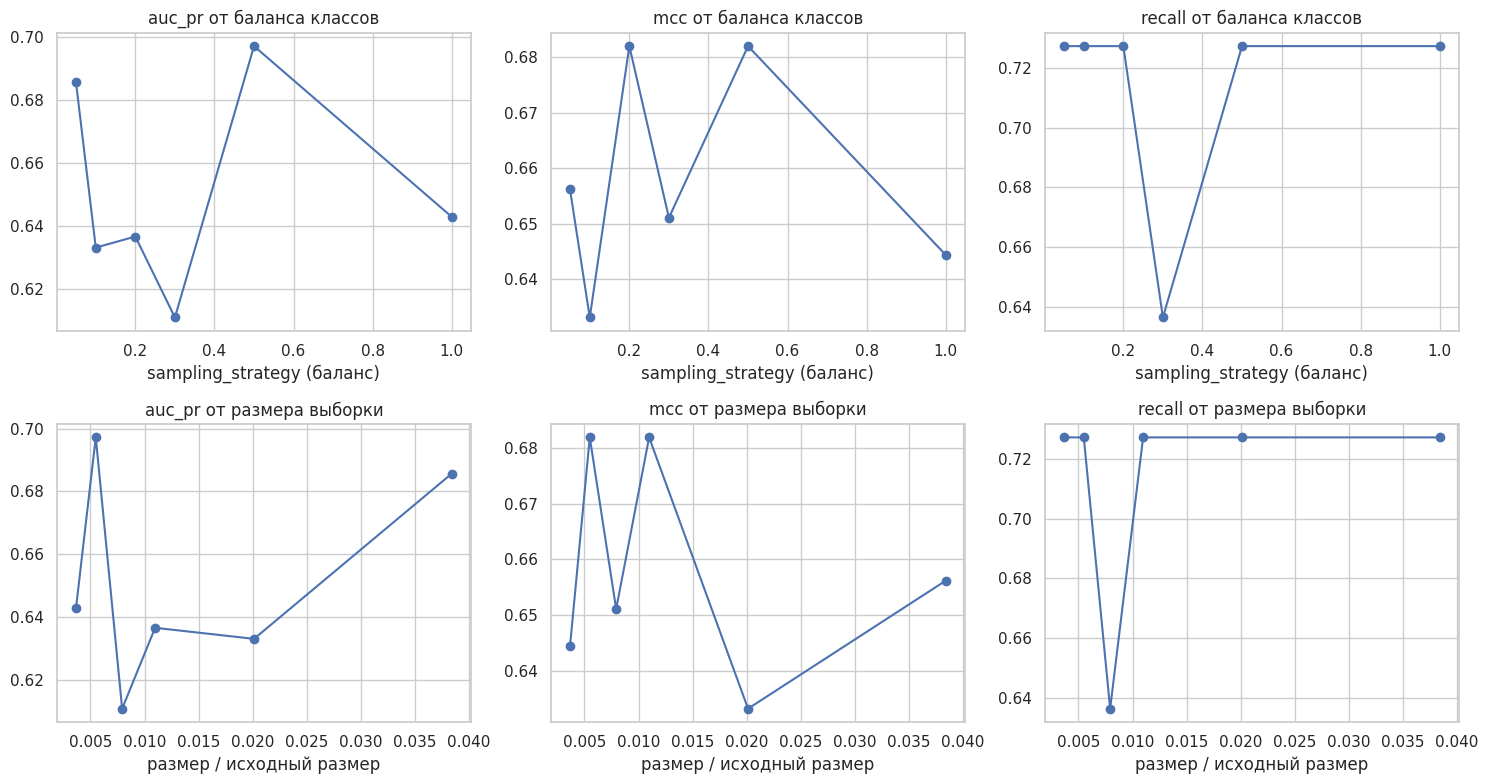

In [58]:
ratios = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
results_under = {'ratio': [], 'size_ratio': [], 'auc_pr': [], 'mcc': [], 'recall': []}

for ratio in ratios:
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    X_res, y_res = rus.fit_resample(X_train, y_train)
    
    m = CatBoostClassifier(iterations=300, verbose=False)
    m.fit(X_res, y_res, eval_set=(X_valid, y_valid))
    
    proba_val = m.predict_proba(X_valid)[:, 1]
    best_mcc, best_t = -1, 0.5
    for t in np.linspace(0, 1, 200):
        y_pred_t = (proba_val >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_valid, y_pred_t).flatten()
        denom = ((tp_+fp_)*(tp_+fn_)*(tn_+fp_)*(tn_+fn_))**0.5
        mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
        if mcc_ > best_mcc:
            best_mcc, best_t = mcc_, t
    
    proba_test = m.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, proba_test)
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= best_t).astype(int)).flatten()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc = (tp * tn - fp * fn) / (denom)
    
    results_under['ratio'].append(ratio)
    results_under['size_ratio'].append(len(X_res) / len(X_train))
    results_under['auc_pr'].append(auc_pr)
    results_under['mcc'].append(mcc)
    results_under['recall'].append(tp / (tp + fn))
    
    print(f'ratio={ratio}  размер: {len(X_res)}  AUC-PR={auc_pr:.4f}  MCC={mcc:.4f}  Recall={tp/(tp+fn):.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (ax, metric) in enumerate(zip(axes[0], ['auc_pr', 'mcc', 'recall'])):
    ax.plot(results_under['ratio'], results_under[metric], marker='o')
    ax.set_title(f'{metric} от баланса классов')
    ax.set_xlabel('sampling_strategy (баланс)')

for i, (ax, metric) in enumerate(zip(axes[1], ['auc_pr', 'mcc', 'recall'])):
    ax.plot(results_under['size_ratio'], results_under[metric], marker='o')
    ax.set_title(f'{metric} от размера выборки')
    ax.set_xlabel('размер / исходный размер')

plt.tight_layout()
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19

ratio=0.05  размер: 8757  AUC-PR=0.6762  MCC=0.6976  Recall=0.6818


/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.1  размер: 4587  AUC-PR=0.6082  MCC=0.6511  Recall=0.6364


/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.2  размер: 2502  AUC-PR=0.5524  MCC=0.6053  Recall=0.5000


/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.3  размер: 1807  AUC-PR=0.5289  MCC=0.6427  Recall=0.4545


/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
/tmp/ipykernel_55/2737460093.py:19: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


ratio=0.5  размер: 1251  AUC-PR=0.6085  MCC=0.5911  Recall=0.4545


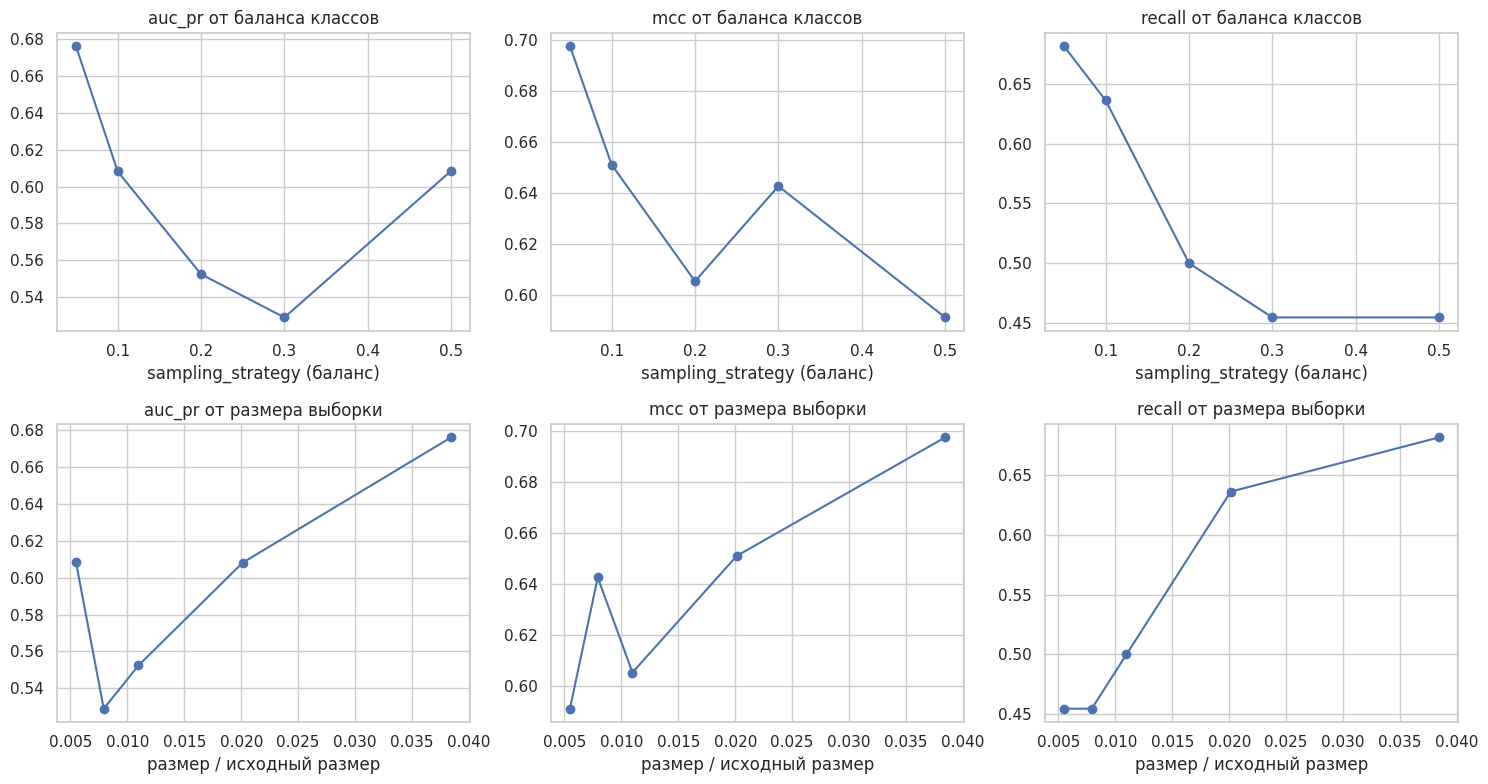

In [60]:
from imblearn.under_sampling import NearMiss

ratios = [0.05, 0.1, 0.2, 0.3, 0.5]
results_nm = {'ratio': [], 'size_ratio': [], 'auc_pr': [], 'mcc': [], 'recall': []}

for ratio in ratios:
    nm = NearMiss(sampling_strategy=ratio)
    X_res, y_res = nm.fit_resample(X_train, y_train)
    
    m = CatBoostClassifier(iterations=300, verbose=False)
    m.fit(X_res, y_res, eval_set=(X_valid, y_valid))
    
    proba_val = m.predict_proba(X_valid)[:, 1]
    best_mcc, best_t = -1, 0.5
    for t in np.linspace(0, 1, 200):
        y_pred_t = (proba_val >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_valid, y_pred_t).ravel()
        denom = ((tp_+fp_)*(tp_+fn_)*(tn_+fp_)*(tn_+fn_))**0.5
        mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
        if mcc_ > best_mcc:
            best_mcc, best_t = mcc_, t
    
    proba_test = m.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, proba_test)
    tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= best_t).astype(int)).flatten()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc = (tp * tn - fp * fn) / (denom)
    
    results_nm['ratio'].append(ratio)
    results_nm['size_ratio'].append(len(X_res) / len(X_train))
    results_nm['auc_pr'].append(auc_pr)
    results_nm['mcc'].append(mcc)
    results_nm['recall'].append(tp / (tp + fn))
    
    print(f'ratio={ratio}  размер: {len(X_res)}  AUC-PR={auc_pr:.4f}  MCC={mcc:.4f}  Recall={tp/(tp+fn):.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, metric in zip(axes[0], ['auc_pr', 'mcc', 'recall']):
    ax.plot(results_nm['ratio'], results_nm[metric], marker='o')
    ax.set_title(f'{metric} от баланса классов')
    ax.set_xlabel('sampling_strategy (баланс)')

for ax, metric in zip(axes[1], ['auc_pr', 'mcc', 'recall']):
    ax.plot(results_nm['size_ratio'], results_nm[metric], marker='o')
    ax.set_title(f'{metric} от размера выборки')
    ax.set_xlabel('размер / исходный размер')

plt.tight_layout()
plt.show()

**Бонус (1 балл)**. imblearn также предлагает много различных методов для андерсэмплинга. Выберите что-нибудь еще из предлагаемого на свой вкус, опишите идею метода и протестируйте его.


выбрал CondensedNearestNeighbour

алгоритм начинает с хранилища из всех фродов и одного случайного не-фрода. потом перебирает все остальные не-фроды и добавляет в хранилище только те которые 1-NN классифицирует неправильно - то есть граничные. Повторяет до сходимости

In [61]:
from imblearn.under_sampling import CondensedNearestNeighbour

cnn = CondensedNearestNeighbour(random_state=42)
X_res, y_res = cnn.fit_resample(X_train, y_train)

print(f'Исходный размер: {len(X_train)}, после: {len(X_res)}')
print(f'Баланс: {y_res.mean()}')

m = CatBoostClassifier(iterations=300, verbose=False)
m.fit(X_res, y_res, eval_set=(X_valid, y_valid))

proba_val = m.predict_proba(X_valid)[:, 1]
best_mcc, best_t = -1, 0.5
for t in np.linspace(0, 1, 200):
    y_pred_t = (proba_val >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_valid, y_pred_t).flatten()
    denom = ((tp_+fp_)*(tp_+fn_)*(tn_+fp_)*(tn_+fn_))**0.5
    mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)
    if mcc_ > best_mcc:
        best_mcc, best_t = mcc_, t

proba_test = m.predict_proba(X_test)[:, 1]
auc_pr = average_precision_score(y_test, proba_test)
tn, fp, fn, tp = confusion_matrix(y_test, (proba_test >= best_t).astype(int)).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn) / (denom)

print(f'AUC-PR={auc_pr}  MCC={mcc:}  Recall={tp/(tp+fn)}  порог={best_t}')

Исходный размер: 227845, после: 2718
Баланс: 0.1534216335540839


/tmp/ipykernel_55/1248615740.py:18: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


AUC-PR=0.6731047928967037  MCC=0.6845372504507213  Recall=0.6363636363636364  порог=0.9748743718592965


/tmp/ipykernel_55/1248615740.py:18: RuntimeWarning: invalid value encountered in scalar divide
  mcc_ = (tp_ * tn_ - fp_ * fn_) / (denom)


# Часть 2. Поиск аномалий. 

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка. 

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных). 

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову). 

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


In [62]:
def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    #your code here
    if n <= 1:
        return 0
    if n == 2:
        return 1
    return 2 * (np.log(n - 1) + 0.5772) - 2 * (n - 1) / n
def calc_height(X, depth, node):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node
        
        depth: int - path length up to current node
        
        node: Node - current tree node
        
    Returns:
        scores: int, float or np.array - anomaly scores for sample
    """


    #your code here
    if node.kind == 'external':
        return depth
    else:
        if X @ node.w + node.b < 0:
            return calc_height(X, depth + 1, node.left)
        else:
            return calc_height(X, depth + 1, node.right)
            
class Node(object):
    """
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.
    
    Attributes:
        X: np.array - data available to current node
        size: int - length of available data
        
        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either "internal" or "external", indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    """
    def __init__(self, X, depth, left, right, kind, w, b):
        """
        Node(h, left, right, kind, w, b)
        Represents the node object.
        
        Params:
            X: np.array - data available to current node
            depth: int - depth of node
            
            left: Node - left child
            right: Node - right child
            
            kind: str - either "internal" or "external", indicates the type of current node
            
            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane
            
        """
        self.size = len(X)
        
        self.depth = depth
        
        self.left = left
        self.right = right
        
        self.kind = kind
    
        self.w = w
        self.b = b
    
    def __repr__(self):
        """
        For convenience only.
        """
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"

class RandomizedTree(object):
    """
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth
        
        max_depth: int - maximum tree depth
        
        root: Node - root node 

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes
        
    """
    def __init__(self, X, max_depth):
        """
        Single randomized tree object. Stores root and its depth (tree is built recursively).
        Params:
            X: np.array - train sample
            max_depth: int - maximum tree depth

        """
        self.depth = 0
        self.max_depth = max_depth
        
        self.internal_count = 0
        self.external_count = 0

        self.root = self.grow(X, 0)
        
    def __repr__(self):
        """
        For convenience only.
        """
        
        return f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})"

        
        
    def grow(self, X, depth):
        """
        Grow tree in a recursive manner.
        Params:
            X: np.array - available train sample
            
            depth: int - current tree depth
            
        Returns:
            node: Node - a trained node with separating hyperplane data.
                         Node provides access to children if necessary (these are built recursively)
        """
        #your code here
            
        if depth == self.max_depth or len(X) <= 1:
            self.external_count += 1
            return Node(X, depth, None, None, 'external', None, None)
        else:
            w = np.random.randn(X.shape[1])
            b = np.random.uniform(min(X @ w), max(X @ w))
            
            left = X @ w + b < 0
            right = X @ w + b >= 0
            X_left = X[left]
            X_right = X[right]
            
            self.internal_count += 1
            left_ = self.grow(X_left, depth + 1)
            right_ = self.grow(X_right, depth + 1)
            
            return Node(X, depth, left_, right_, 'internal', w, b)

    def score_samples(self, X):
        """
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated
            
        Returns:
            scores: np.array - estimated anomaly scores
        """
        #your code here

        scores = []
        for x in X:
            scores.append(calc_height(x, 0, self.root))
        return np.array(scores)

        
        
    
class ExtendedIsolationForest(object):
    """
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees
        
        max_depth: int - maximum depth of each tree
        
        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree
        
        trees: list - container for trained trees 
        
        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding
        
    """
    
    def __init__(self, n_trees, subsample_rate, max_depth=None, contamination=0.01):
        """
        Extended Isolation Forest object. Stores training data and trained randomized trees.
        Params:
            n_trees: int - number of Randomized Trees

            subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

            max_depth: int or None - maximum depth of each tree. Defaults to ceil(log_2(subsample_size)) if not provided

            contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.contamination = contamination
        self.is_fit = False
        
    def __repr__(self):
        """For convenience only."""
        
        return f"ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})"
        
    def fit(self, X):
        """
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        """
        #your code here
        subsample_size = int(self.subsample_rate * X.shape[0])
    
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(subsample_size)))
        
        for _ in range(self.n_trees):
            idx = np.random.choice(X.shape[0], size=subsample_size, replace=False)
            X_sub = X[idx]
            tree = RandomizedTree(X_sub, self.max_depth)
            self.trees.append(tree)
        
        self.is_fit = True
        return self
        
    def score_samples(self, X):
        """
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        """
        #your code here
        scores = np.zeros(X.shape[0])
        for tr in self.trees:
            scores += tr.score_samples(X)/len(self.trees)
        scores /= c_factor(int(self.subsample_rate * X.shape[0]))
        return scores

    
    def predict(self, X):
        """
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        """
        #your code here
        scores = self.score_samples(X)
        threshold = np.quantile(scores, self.contamination)
        labels = (scores <= threshold).astype(int)

        return labels


**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [73]:
best_auc, best_n, best_mcc_val, best_recall = -1, None, None, None

for n_trees in [10, 50, 100, 200, 500]:
    eif = ExtendedIsolationForest(n_trees=n_trees, subsample_rate=256/len(X_train), contamination=float(y_train.mean()))
    eif.fit(X_train_scaled)
    eif_scores = eif.score_samples(X_test_scaled)
    eif_pred = eif.predict(X_test_scaled)
    
    tn, fp, fn, tp = confusion_matrix(y_test, eif_pred).flatten()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    auc_pr = average_precision_score(y_test, -eif_scores)
    mcc = (tp * tn - fp * fn) / (denom + 1e-10)
    recall = tp / (tp + fn)
    
    print(f'n_trees={n_trees}  AUC-PR={auc_pr}  MCC={mcc}  Recall={recall}')
    
    if auc_pr > best_auc:
        best_auc, best_n, best_mcc_val, best_recall = auc_pr, n_trees, mcc, recall

print(f'Лучший n_trees={best_n}  AUC-PR={best_auc}  MCC={best_mcc_val}  Recall={best_recall}')

n_trees=10  AUC-PR=0.019112398465690645  MCC=-0.0012229958729041504  Recall=0.0
n_trees=50  AUC-PR=0.02996010358968236  MCC=0.08677144329238742  Recall=0.13636363636363635
n_trees=100  AUC-PR=0.03665237036904503  MCC=0.0859433206948107  Recall=0.13636363636363635
n_trees=200  AUC-PR=0.03829888226699553  MCC=0.0859433206948107  Recall=0.13636363636363635
n_trees=500  AUC-PR=0.03626536118748582  MCC=0.028123473468817856  Recall=0.045454545454545456
Лучший n_trees=200  AUC-PR=0.03829888226699553  MCC=0.0859433206948107  Recall=0.13636363636363635


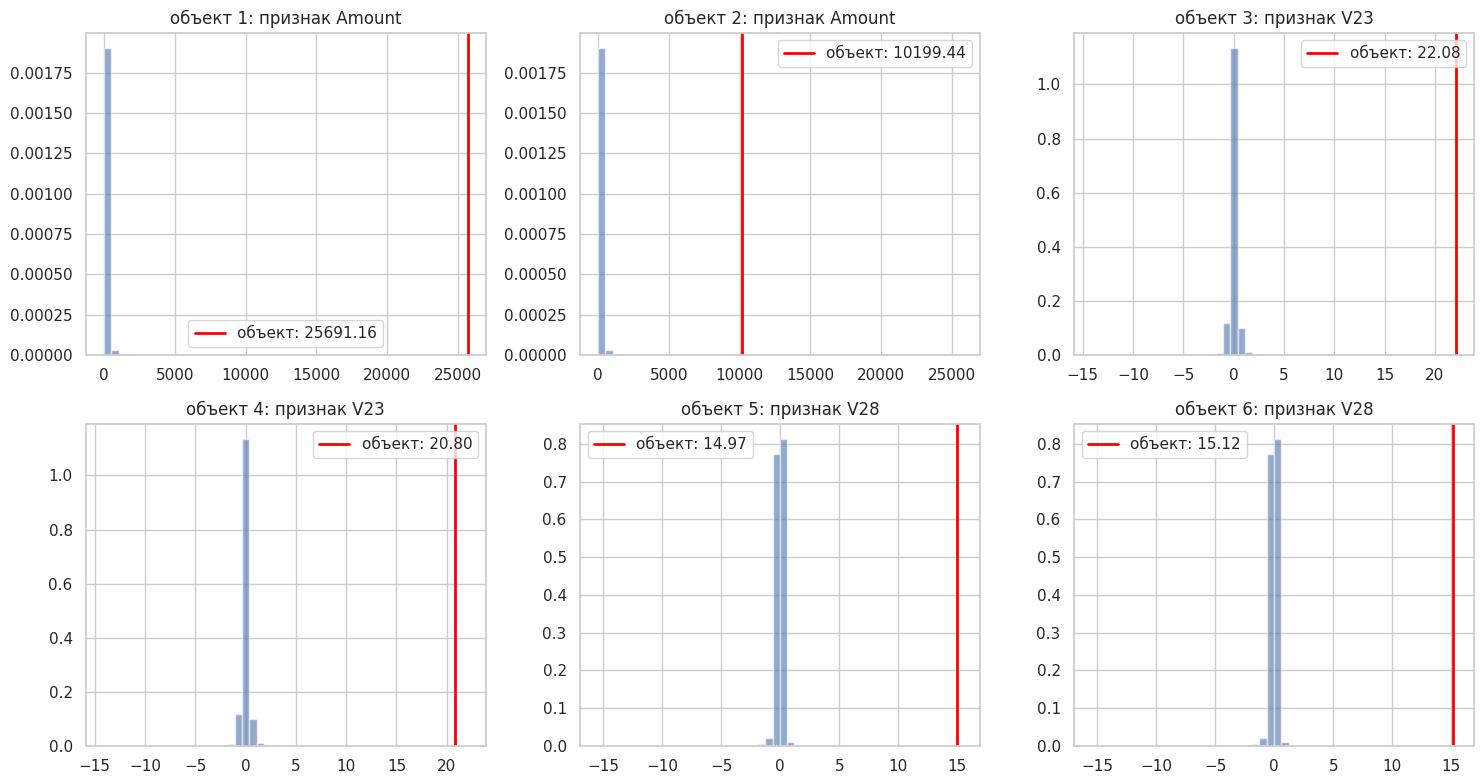

In [78]:
false_pos = test_with_scores[test_with_scores['Class'] == 0].nlargest(6, 'eif_score')

features_only = [c for c in X_test.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (idx, row) in enumerate(false_pos.iterrows()):

    z_scores = ((row[features_only] - test_with_scores[features_only].mean()) / test_with_scores[features_only].std()).abs()
    worst_feature = z_scores.idxmax()
    ax = axes[i // 3][i % 3]
    ax.hist(test_with_scores[worst_feature], bins=50, density=True, alpha=0.6)
    ax.axvline(row[worst_feature], color='red', linewidth=2, label=f'объект: {row[worst_feature]:.2f}')
    ax.set_title(f'объект {i+1}: признак {worst_feature}')
    ax.legend()

plt.tight_layout()
plt.show()

Вот мы и видим почему так получается. То в чем наша модель была уверена что это фрод просто имеет выброс по одному из признаков, из за чего сразу деревом выкидывается

Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

In [79]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators=200, contamination=y_train.mean(), random_state=42)
clf.fit(X_train_scaled)
if_scores = -clf.score_samples(X_test_scaled)  
if_pred = (clf.predict(X_test_scaled) == -1).astype(int) 

tn, fp, fn, tp = confusion_matrix(y_test, if_pred).flatten()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
auc_pr = average_precision_score(y_test, if_scores)
mcc = (tp * tn - fp * fn) / (denom)

print(f'IF: AUC-PR={auc_pr}  MCC={mcc}  Recall={tp/(tp+fn)}')

IF: AUC-PR=0.019424168655340246  MCC=-0.0008722008514868773  Recall=0.0


самодельный EIF использует произвольные гиперплоскости для разбиения пространства, что позволяет лучше изолировать аномалии в данных с коррелированными признаками, тогда как стандартный IF разбивает пространство только по одному признаку за раз

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [83]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

lof = LocalOutlierFactor(contamination=float(y_train.mean()))
lof_pred = (lof.fit_predict(X_test_scaled) == -1).astype(int)
lof_scores = -lof.negative_outlier_factor_

tn, fp, fn, tp = confusion_matrix(y_test, lof_pred).ravel()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
auc_pr = average_precision_score(y_test, lof_scores)
mcc = (tp * tn - fp * fn) / (denom )
print(f'LOF: AUC-PR={auc_pr}  MCC={mcc}  Recall={tp/(tp+fn)}')

ocsvm = OneClassSVM(nu=float(y_train.mean()))
ocsvm.fit(X_train_scaled)
ocsvm_pred = (ocsvm.predict(X_test_scaled) == -1).astype(int)
ocsvm_scores = -ocsvm.score_samples(X_test_scaled)

tn, fp, fn, tp = confusion_matrix(y_test, ocsvm_pred).ravel()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
auc_pr = average_precision_score(y_test, ocsvm_scores)
mcc = (tp * tn - fp * fn) / (denom)
print(f'OCSVM: AUC-PR={auc_pr}  MCC={mcc}  Recall={tp/(tp+fn)}')

LOF: AUC-PR=0.009764037410178783  MCC=0.057447458380602646  Recall=0.09090909090909091
OCSVM: AUC-PR=0.022447302215722217  MCC=0.08400098921500737  Recall=0.45454545454545453


все четыре метода показали слабые результаты - AUC-PR не превышает 0.04 ни у одного. OCSVM выделяется recall 0.45, но ценой большого числа ложных срабатываний. это ожидаемо: фродовые транзакции в этом датасете не являются статистическими выбросами, они просто другие — и без разметки это не поймать

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

In [ ]:
eif = ExtendedIsolationForest(n_trees=100, subsample_rate=256/len(X_train), contamination=float(y_train.mean()))
eif.fit(X_train_scaled)
clf_if = IsolationForest(n_estimators=100, contamination=float(y_train.mean()), random_state=42)
clf_if.fit(X_train_scaled)
ocsvm = OneClassSVM(nu=float(y_train.mean()))
ocsvm.fit(X_train_scaled)
lof = LocalOutlierFactor(contamination=float(y_train.mean()), novelty=True)
lof.fit(X_train_scaled)

X_valid_scaled = scaler.transform(X_valid)

X_train_new = X_train.copy()
X_train_new['eif_score'] = -eif.score_samples(X_train_scaled)
X_train_new['if_score'] = -clf_if.score_samples(X_train_scaled)
X_train_new['ocsvm_score'] = -ocsvm.score_samples(X_train_scaled)
X_train_new['lof_score'] = -lof.score_samples(X_train_scaled)

X_valid_new = X_valid.copy()
X_valid_new['eif_score'] = -eif.score_samples(X_valid_scaled)
X_valid_new['if_score'] = -clf_if.score_samples(X_valid_scaled)
X_valid_new['ocsvm_score'] = -ocsvm.score_samples(X_valid_scaled)
X_valid_new['lof_score'] = -lof.score_samples(X_valid_scaled)

X_test_new = X_test.copy()
X_test_new['eif_score'] = -eif.score_samples(X_test_scaled)
X_test_new['if_score'] = -clf_if.score_samples(X_test_scaled)
X_test_new['ocsvm_score'] = -ocsvm.score_samples(X_test_scaled)
X_test_new['lof_score'] = -lof.score_samples(X_test_scaled)

scale = 1/df['Class'].mean() - 1
model_new = CatBoostClassifier(verbose=100, scale_pos_weight=scale)
model_new.fit(X_train_new, y_train, eval_set=(X_valid_new, y_valid))

y_pred = model_new.predict(X_test_new)
y_proba = model_new.predict_proba(X_test_new)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
mcc = (tp * tn - fp * fn) / (denom )
auc_pr = average_precision_score(y_test, y_proba)

print(f'MCC={mcc}  AUC-PR={auc_pr}  Recall={tp/(tp+fn)}')

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла. 

Если вы хотите отказаться от сдачи данного задания, допишите "хочу" после двоеточия: `your text here`

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [ ]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)